In [53]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [54]:
df = pd.read_csv('data/student.csv')

In [55]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [56]:
X = df.drop(columns=['math_score'], axis=1)

In [57]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [58]:
print("Categories in 'gender' variable: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ", end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" ")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:  ['female' 'male']
Categories in 'race_ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [59]:
y = df['math_score']

In [60]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [61]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", oh_transformer, cat_features),
    ]
)

In [62]:
X = preprocessor.fit_transform(X)

In [63]:
X

array([[ 0.19399858,  0.39149181,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42747598,  1.31326868,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.77010859,  1.64247471,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.12547206, -0.20107904,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60515772,  0.58901542,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.15336989,  1.18158627,  1.        , ...,  0.        ,
         0.        ,  1.        ]], shape=(1000, 19))

In [64]:
X.shape

(1000, 19)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [67]:
def evaluate_model(true, predicted):
    """
    Evaluate regression model performance.

    Parameters:
    -----------
    true : array-like
        True target values.
    predicted : array-like
        Predicted target values.

    Returns:
    --------
    mae : float
        Mean Absolute Error
    rmse : float
        Root Mean Squared Error
    r2 : float
        R-squared score
    """
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [68]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "SVR": SVR(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

In [69]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

print("R2 scores for test set:", r2_list)

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7128
- Mean Absolute Error: 4.5168
- R2 Score: 0.8552
-----------------------

In [70]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
9,AdaBoost Regressor,0.856472
5,Random Forest Regressor,0.852962
8,CatBoosting Regressor,0.851632
1,Lasso,0.825320
7,XGBRegressor,0.821221
3,K-Neighbors Regressor,0.783770
4,Decision Tree,0.745190
6,SVR,0.728600


In [87]:
model_list = []
r2_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2_percent = r2_score(y_test, y_pred) * 100

    model_list.append(name)
    r2_list.append(round(r2_percent, 2))

results_df = pd.DataFrame({
    "Model Name": model_list,
    "R2_Score (%)": r2_list
}).sort_values(by="R2_Score (%)", ascending=False)

results_df

,Model Name,R2_Score (%)
2,Ridge,88.06
0,Linear Regression,88.04
5,Random Forest Regressor,85.19
8,CatBoosting Regressor,85.16
9,AdaBoost Regressor,84.55
1,Lasso,82.53
7,XGBRegressor,82.12
3,K-Neighbors Regressor,78.38
4,Decision Tree,73.46
6,SVR,72.86


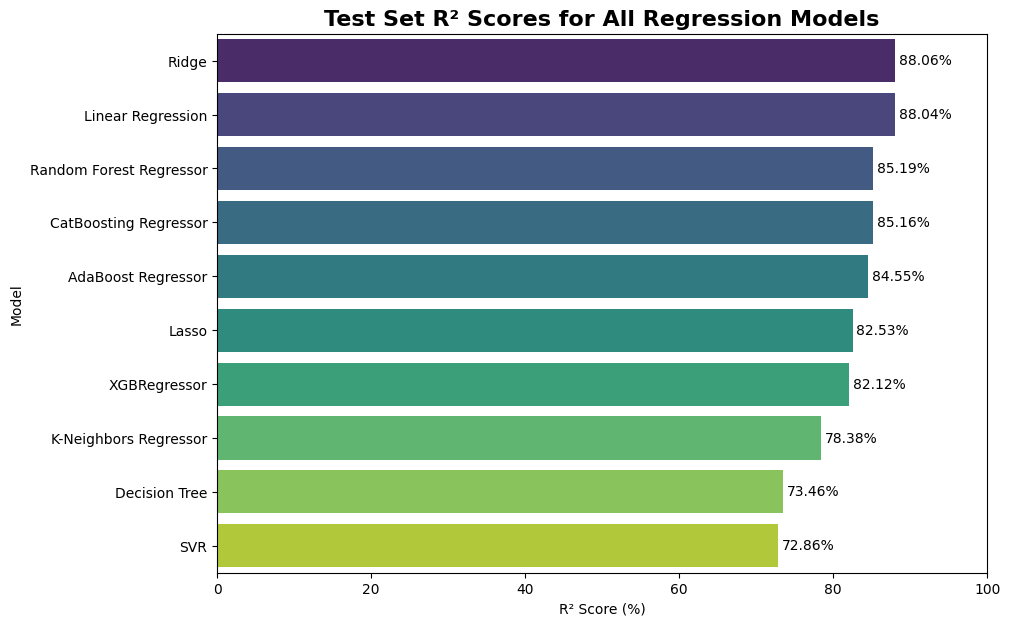

In [90]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x="R2_Score (%)",
    y="Model Name",
    hue="Model Name",
    palette="viridis",
    legend=False
)

plt.title("Test Set R² Scores for All Regression Models", fontsize=16, fontweight='bold')
plt.xlabel("R² Score (%)")
plt.ylabel("Model")
plt.xlim(0, 100)

for index, value in enumerate(results_df["R2_Score (%)"]):
    plt.text(value + 0.5, index, f"{value:.2f}%", va="center")

plt.subplots_adjust(left=0.35)
plt.show()

In [91]:
num_models = len(models)
cols = 3 
rows = math.ceil(num_models / cols)

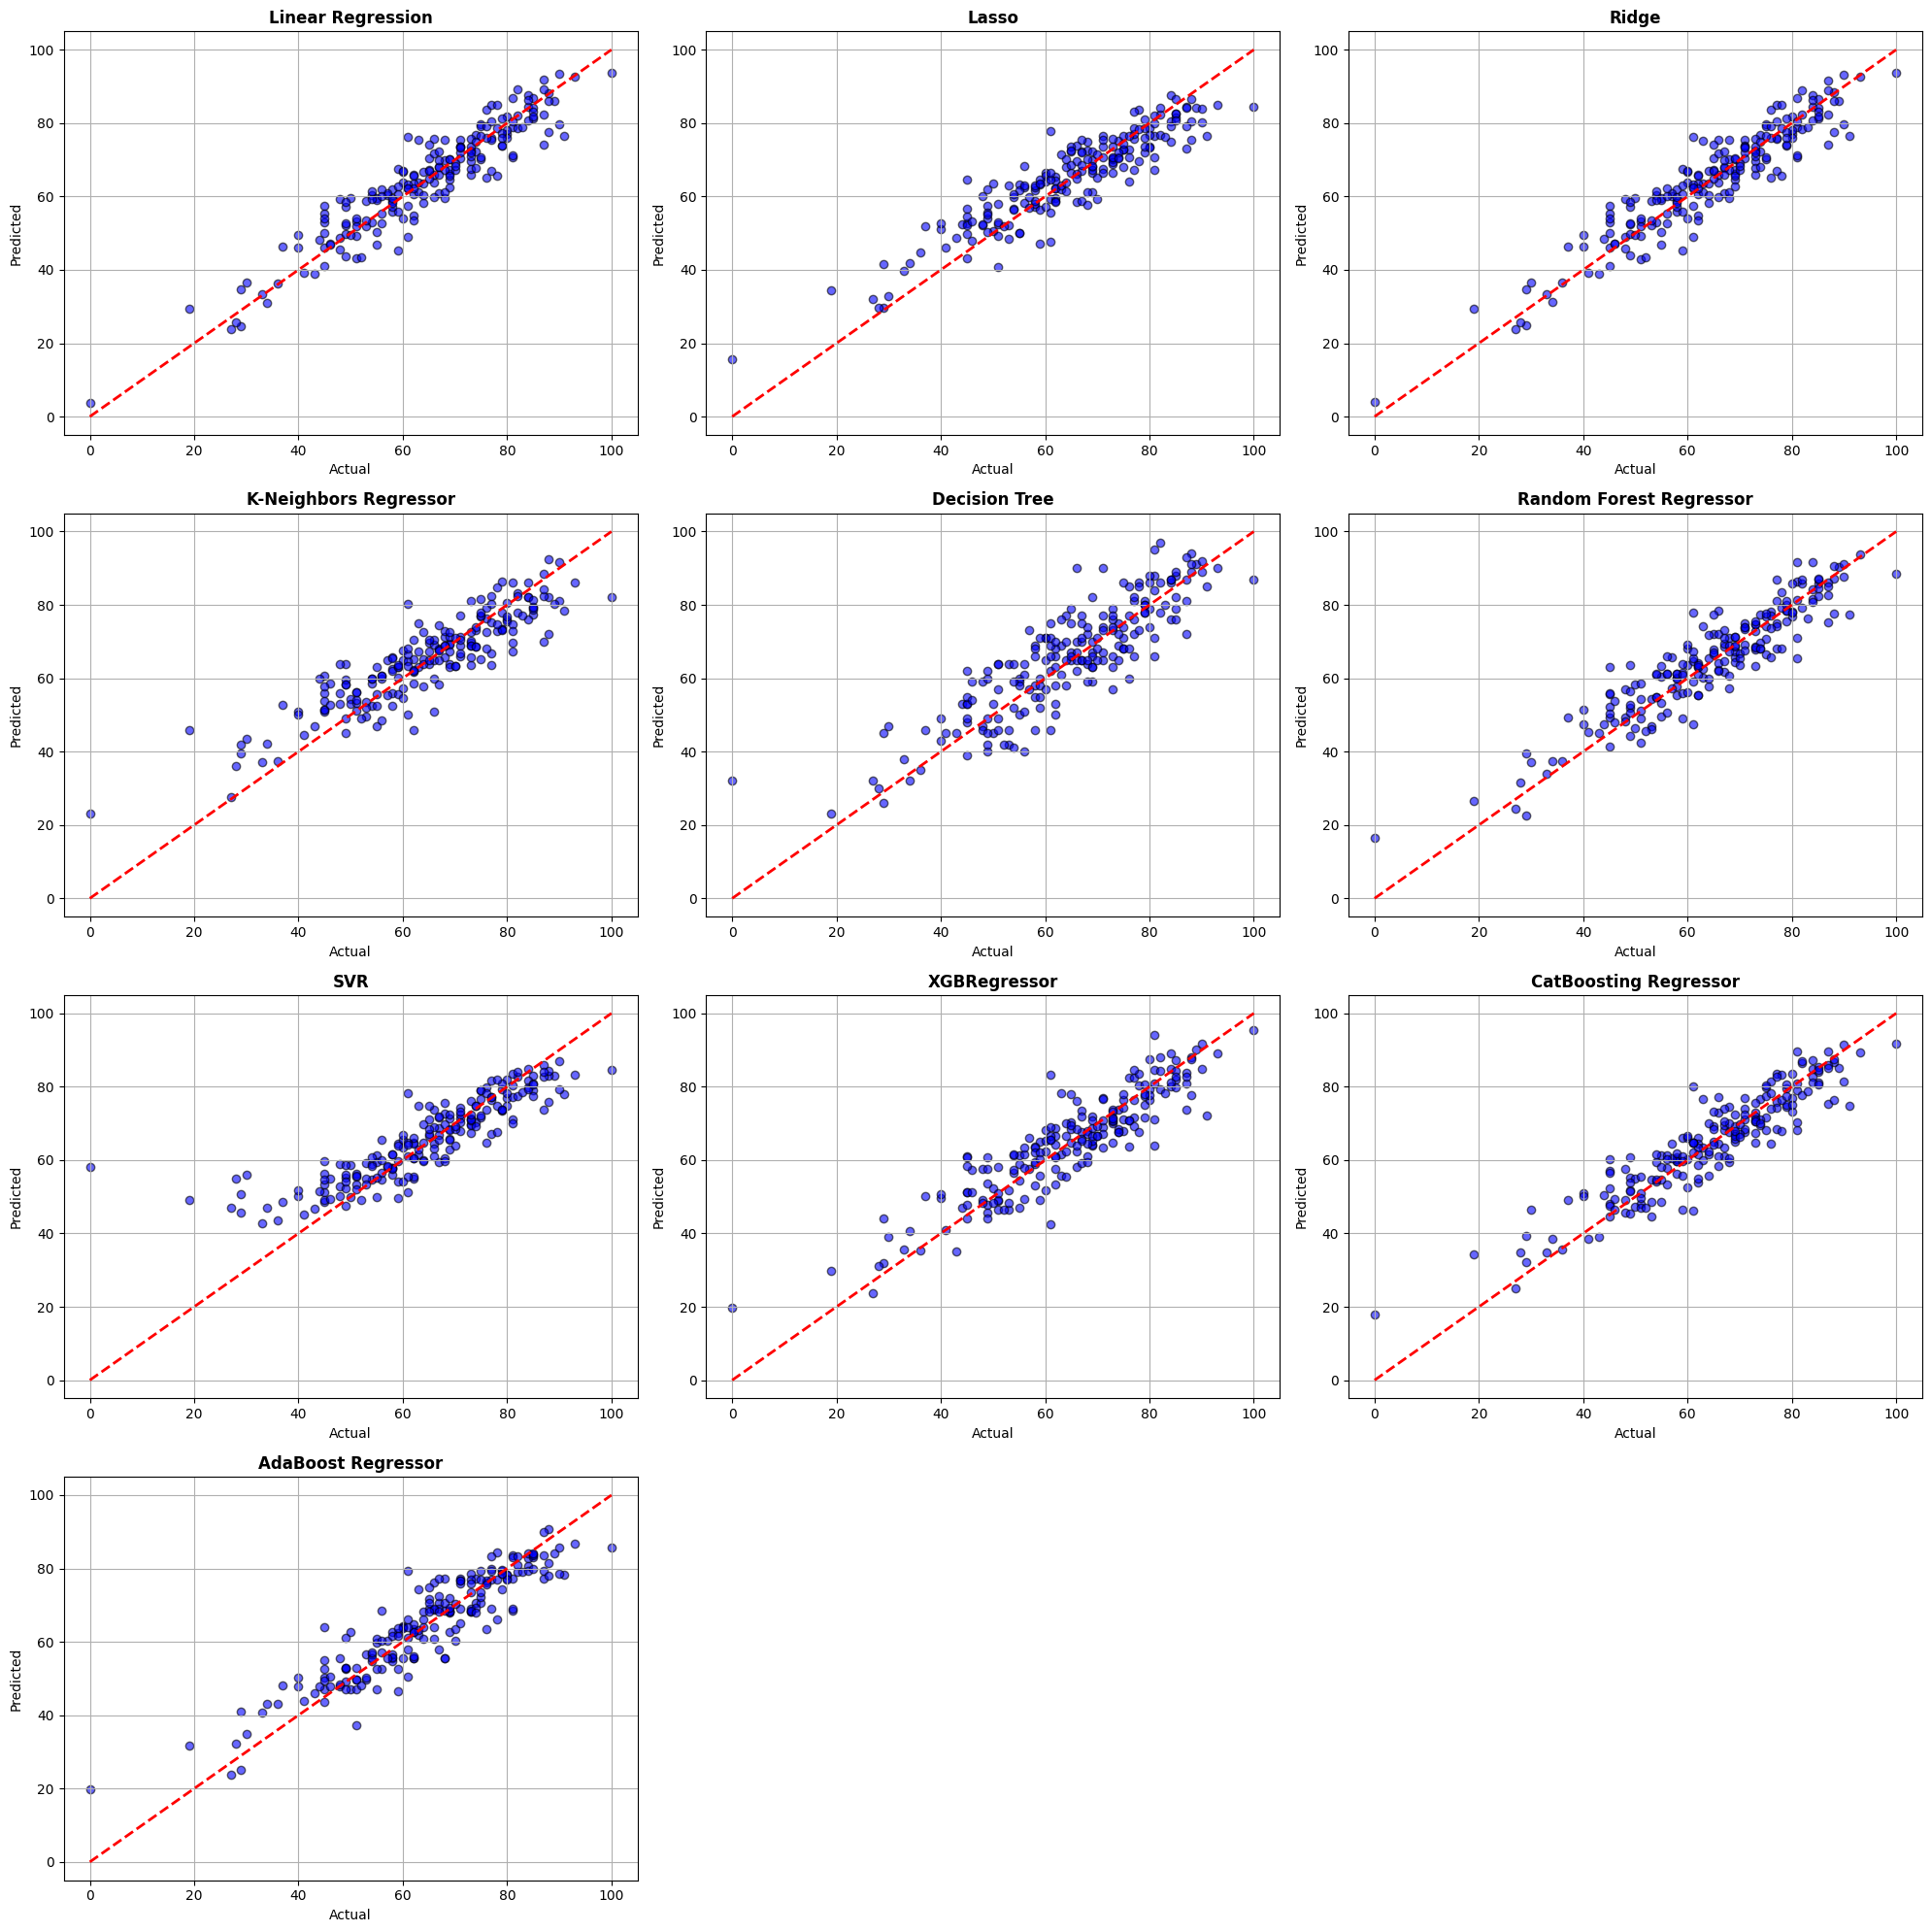

In [92]:
plt.figure(figsize=(20, rows * 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    
    plt.subplot(rows, cols, i + 1)
    plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name}', fontsize=12, fontweight='bold')
    plt.grid(True)

plt.tight_layout()
plt.show()

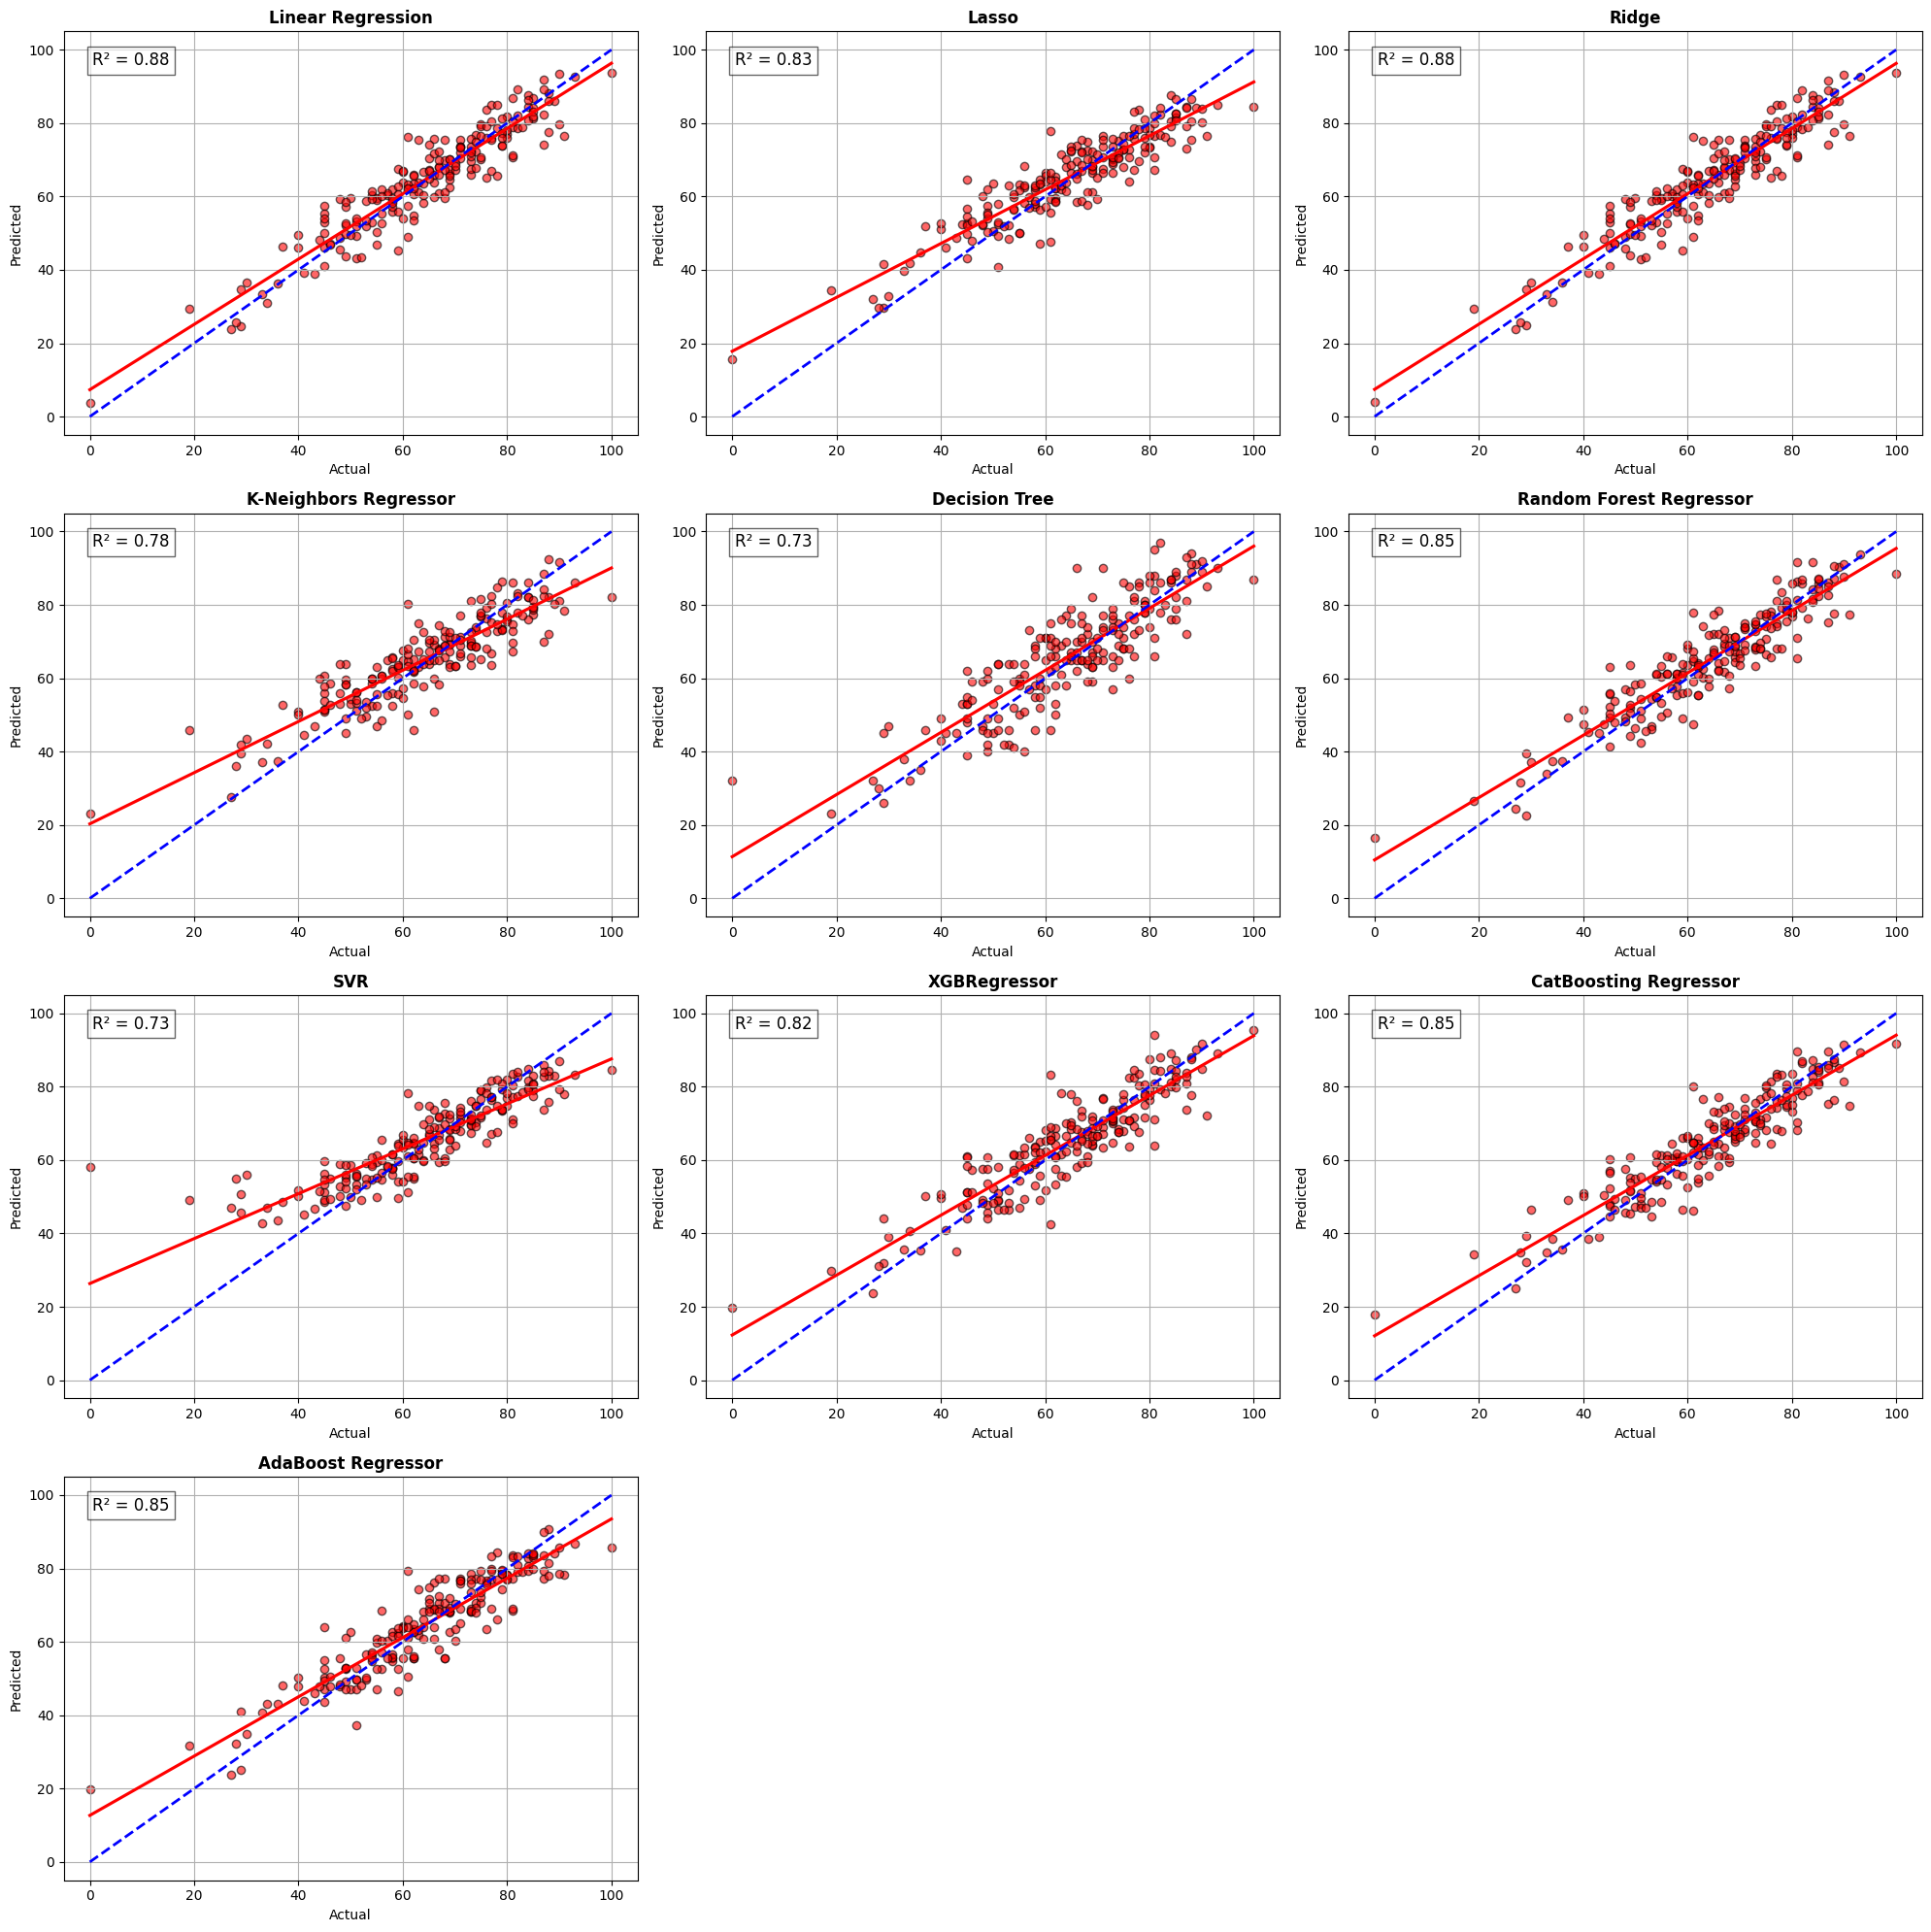

In [93]:
plt.figure(figsize=(20, rows * 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    
    plt.subplot(rows, cols, i + 1)
    sns.regplot(x=y_test, y=y_pred, ci=None, color='red', 
                scatter_kws={'alpha':0.6, 'edgecolor':'k'})
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2)
    
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name}', fontsize=12, fontweight='bold')
    plt.grid(True)
    
    r2 = r2_score(y_test, y_pred)
    plt.text(0.05, 0.95, f'R² = {r2:.2f}', transform=plt.gca().transAxes, 
             fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))

plt.tight_layout()
plt.show()

In [94]:
all_preds_df = pd.DataFrame({'Actual': y_test.reset_index(drop=True)})

for name, model in models.items():
    preds = model.predict(X_test)
    actual = y_test.reset_index(drop=True)
    
    all_preds_df[f'{name} Predicted'] = preds
    all_preds_df[f'{name} Difference'] = actual - preds
    all_preds_df[f'{name} % Error'] = ((actual - preds) / actual) * 100

all_preds_df.head()

,Actual,Linear Regression Predicted,Linear Regression Difference,Linear Regression % Error,Lasso Predicted,Lasso Difference,Lasso % Error,Ridge Predicted,Ridge Difference,Ridge % Error,...,SVR % Error,XGBRegressor Predicted,XGBRegressor Difference,XGBRegressor % Error,CatBoosting Regressor Predicted,CatBoosting Regressor Difference,CatBoosting Regressor % Error,AdaBoost Regressor Predicted,AdaBoost Regressor Difference,AdaBoost Regressor % Error
0,91,76.387970,14.612030,16.057176,76.485567,14.514433,15.949927,76.398705,14.601295,16.045379,...,14.401646,72.256554,18.743446,20.597194,74.709499,16.290501,17.901650,78.418803,12.581197,13.825491
1,53,58.885970,-5.885970,-11.105604,63.009978,-10.009978,-18.886751,58.842469,-5.842469,-11.023526,...,-11.616554,51.827824,1.172176,2.211654,54.706876,-1.706876,-3.220521,56.590476,-3.590476,-6.774483
2,80,76.990265,3.009735,3.762169,73.675788,6.324212,7.905265,76.992129,3.007871,3.759839,...,3.891102,79.382545,0.617455,0.771818,76.842097,3.157903,3.947378,77.223022,2.776978,3.471223
3,74,76.851804,-2.851804,-3.853790,75.237686,-1.237686,-1.672549,76.805898,-2.805898,-3.791754,...,-1.057661,73.846962,0.153038,0.206808,76.580288,-2.580288,-3.486876,77.223022,-3.223022,-4.355435
4,84,87.627378,-3.627378,-4.318307,80.373101,3.626899,4.317737,87.615387,-3.615387,-4.304033,...,-1.143264,84.875084,-0.875084,-1.041767,87.297491,-3.297491,-3.925585,82.880435,1.119565,1.332816
